#  Notebook 3 · Đánh giá Mô hình & Phân tích Chuyên sâu (XAI)

**Mục tiêu:** Đánh giá khách quan hiệu năng mô hình trên **tập kiểm thử độc lập** (15% dữ liệu chưa từng xuất hiện trong quá trình huấn luyện) và giải thích quyết định của mô hình thông qua kỹ thuật **Grad-CAM**.

---

### Pipeline Đánh giá

```
test_df.csv  ──►  Resize 224×224  ──►  Model.predict()  ──►  Metrics & Reports ──►  Grad-CAM Heatmap

```






In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import glob
import random
import os
from sklearn.metrics import classification_report, confusion_matrix

# Load model final
MODEL_PATH = "../models/smoker_detector_best.keras"
 

# Load model với custom_objects để Keras hiểu lớp Lambda
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        'preprocess_input': tf.keras.applications.mobilenet_v2.preprocess_input
    },
    safe_mode=False
)

print("Đã tải mô hình thành công!")
model.summary()



Đã tải mô hình thành công!
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 lambda (Lambda)             (None, 224, 224, 3)          0         ['input_2[0][0]']             
                                                                                                  
 model (Functional)          [(None, 28, 28, 192),        2257984   ['lambda[0][0]']              
                              (None, 7, 7, 1280)]                                                 
                                                                                                  
 conv2d (Conv2D)             (None, 28, 28, 256)          44262

In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TEST_DIR = "../dataset/processed_dataset"
TEST_CSV_PATH = os.path.join(TEST_DIR, "test_dataset.csv")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

if not os.path.exists(TEST_CSV_PATH):
    raise FileNotFoundError(f"Không tìm thấy {TEST_CSV_PATH}. Vui lòng chạy Notebook 2 để chia tập test.")

# Đọc file CSV chứa danh sách ảnh test
test_df = pd.read_csv(TEST_CSV_PATH)
print(f"Đã nạp {len(test_df)} ảnh từ test_df.csv")

# Tải dữ liệu bằng ImageDataGenerator (chỉ để nạp ảnh, không augment)
test_gen = ImageDataGenerator().flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False # Quan trọng: Không xáo trộn để lấy nhãn đúng thứ tự
)

class_names = list(test_gen.class_indices.keys())

#  Lấy Nhãn Thực Tế và Nhãn Dự Đoán
print("Đang chạy dự đoán trên tập Test...")
# Vì shuffle=False nên classes từ gen sẽ theo đúng thứ tự file
y_true_indices = test_gen.classes

# Dự đoán toàn bộ tập test
preds = model.predict(test_gen, verbose=1)
y_pred_indices = np.argmax(preds, axis=1)

# Chuyển về dạng numpy array để vẽ biểu đồ
y_true_indices = np.array(y_true_indices)
y_pred_indices = np.array(y_pred_indices)

# 4. Đánh giá tổng quan
loss, acc = model.evaluate(test_gen, verbose=0) 
print(f"\n📊 Accuracy: {acc*100:.2f}% | Loss: {loss:.4f}")



Đã nạp 461 ảnh từ test_dataset.csv
Found 461 validated image filenames belonging to 2 classes.
Đang chạy dự đoán trên tập Test...
15/15 [==============================] - 11s 696ms/step



📊 Accuracy: 83.95% | Loss: 0.3811



BÁO CÁO CHI TIẾT (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

 not_smoking       0.81      0.84      0.83       225
     smoking       0.84      0.82      0.83       237

    accuracy                           0.83       462
   macro avg       0.83      0.83      0.83       462
weighted avg       0.83      0.83      0.83       462



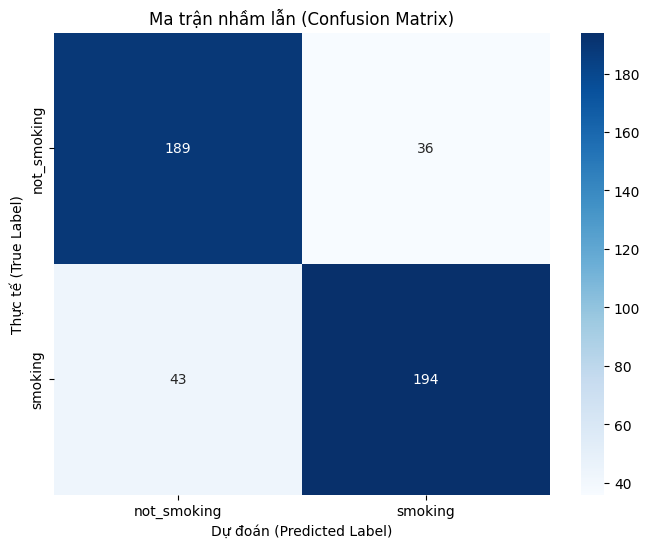

In [3]:
# In Classification Report
print("\n" + "="*60)
print("BÁO CÁO CHI TIẾT (CLASSIFICATION REPORT)")
print("="*60)
print(classification_report(y_true_indices, y_pred_indices, target_names=class_names))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_true_indices, y_pred_indices)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.show()  

Đang chạy dự đoán và khởi tạo Grad-CAM cho 10 ảnh...


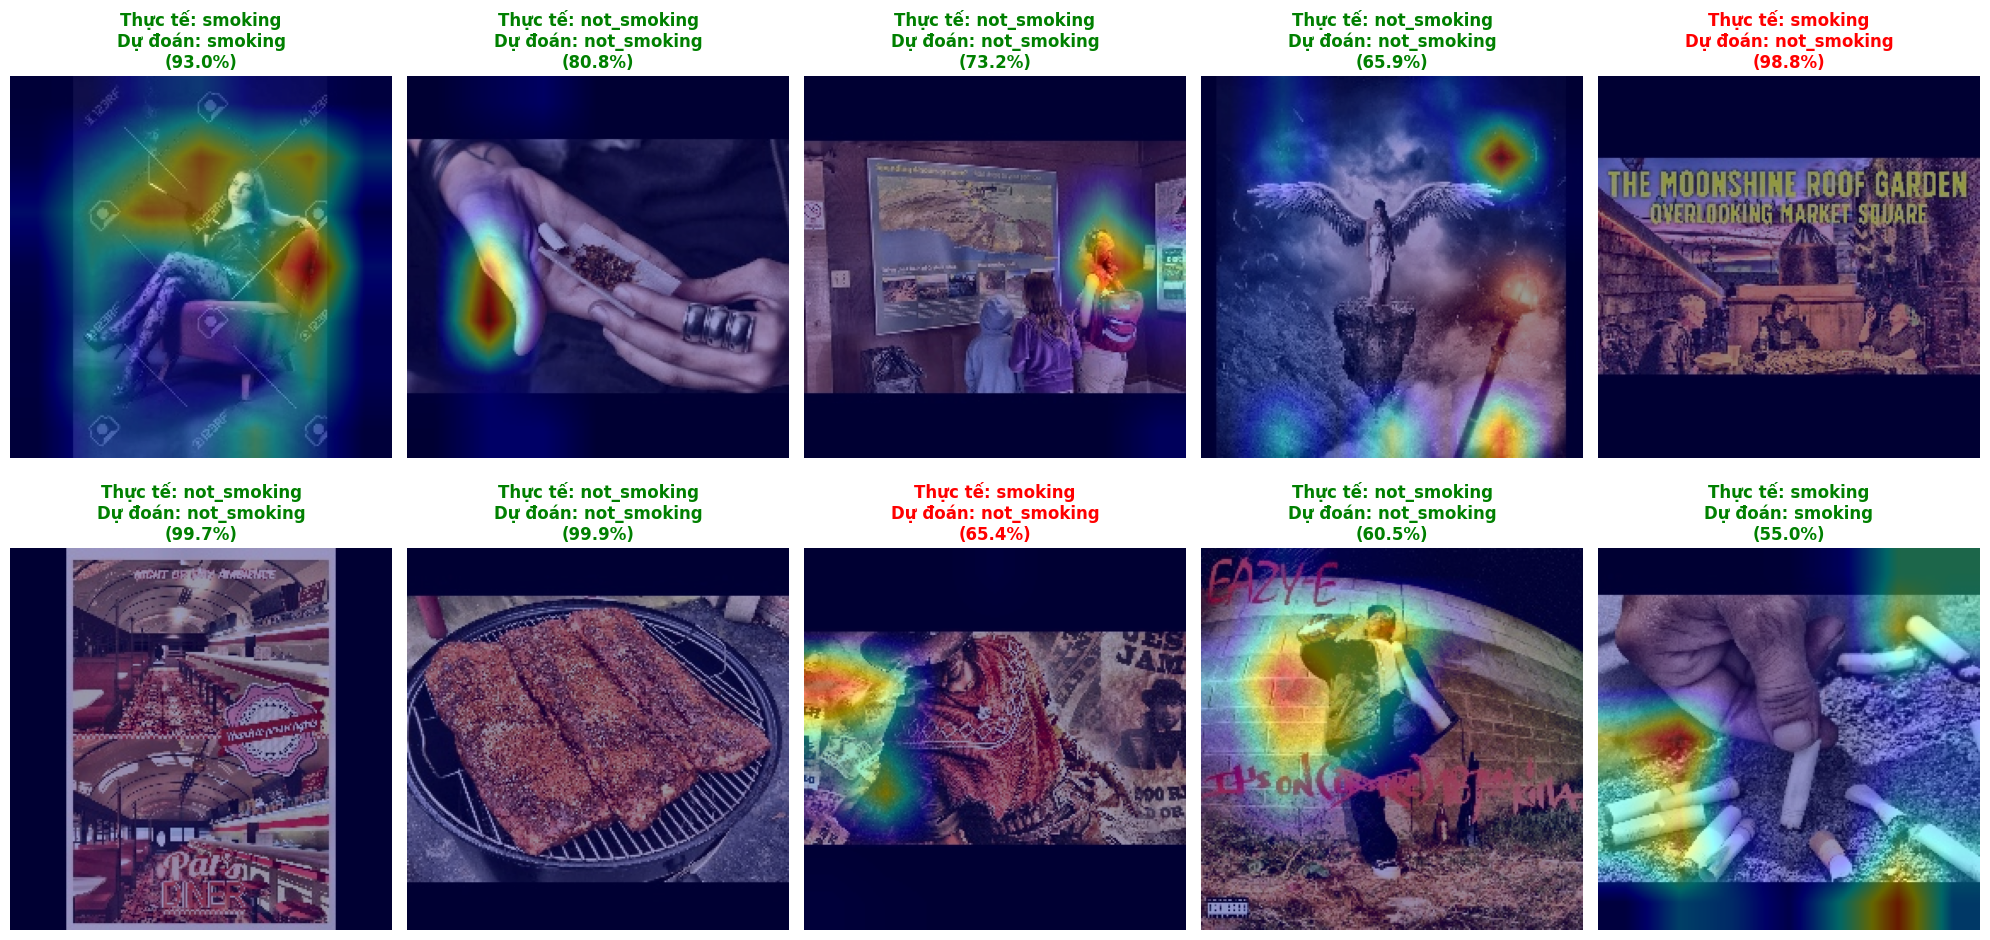

In [ ]:

# --- ĐỊNH NGHĨA HÀM GRAD-CAM ---
def make_gradcam_heatmap(img_array, model, branch='deep'):
    
    if branch == 'deep':
        target_layer = model.get_layer('pool_smoke')
    elif branch == 'shallow':
        target_layer = model.get_layer('pool_cigarette')
    else:
        raise ValueError("branch phải là 'deep' hoặc 'shallow'")

    target_feature_map = target_layer.input
    
    if isinstance(target_feature_map, list):
        target_feature_map = target_feature_map[-1]

    # Tạo mô hình trung gian
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[target_feature_map, model.output]
    )

    # Tính Gradient
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if isinstance(predictions, list):
            predictions = predictions[-1]
        # Ta luôn bắt sáng Grad-CAM cho class 1 (smoking) 
        # để biết mô hình nhìn vào đâu khi quyết định có khói/thuốc.
        class_channel = predictions[:, 1]

    # Gradient của feature map
    grads = tape.gradient(class_channel, conv_outputs)

    # Tính trung bình gradient (Global Average Pooling cho Grad)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Nhân ma trận
    # conv_outputs có dạng (1, H, W, C)
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Chuẩn hóa
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val
    return heatmap.numpy()

# --- HÀM TẠO ẢNH GRAD-CAM (Phủ màu lên ảnh gốc) ---
def get_superimposed_img(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

# --- TRỰC QUAN HÓA 10 ẢNH MẪU CÙNG LÚC ---
# Lấy danh sách toàn bộ ảnh test từ DataFrame
test_files = test_df['Filepath'].tolist()

# Tên lớp chuẩn
class_names = list(test_gen.class_indices.keys()) if 'test_gen' in locals() else ['not_smoking', 'smoking'] 

if len(test_files) >= 10:
    # Chọn ngẫu nhiên 10 ảnh
    sample_paths = random.sample(test_files, 10)
    plt.figure(figsize=(20, 10)) # Kích thước khung hình lớn
    print("Đang chạy dự đoán và khởi tạo Grad-CAM cho 10 ảnh...")
    
    for i, path in enumerate(sample_paths):
        # 1. Trích xuất Nhãn Thực Tế từ tên thư mục chứa ảnh
        true_label = os.path.basename(os.path.dirname(path))
        
        # 2. Tiền xử lý ảnh chuẩn RGB 
        raw_img = cv2.imread(path)
        test_img = cv2.resize(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB), (224, 224))
        img_arr = test_img[np.newaxis, ...].astype('float32')
        
        # 3. Mô hình dự đoán
        preds = model.predict(img_arr, verbose=0)
        if isinstance(preds, list):
            preds = preds[-1]
        pred_idx = np.argmax(preds[0])
        pred_label = class_names[pred_idx]
        confidence = preds[0][pred_idx] * 100
        
        # 4. Tính toán Grad-CAM
        heatmap = make_gradcam_heatmap(img_arr, model, branch='deep')
        gradcam_img = get_superimposed_img(path, heatmap)
        
        # 5. Đưa lên lưới đồ thị (Subplot 2 hàng, 5 cột)
        plt.subplot(2, 5, i + 1)
        plt.imshow(gradcam_img)
        
        # Đặt màu chữ: Xanh nếu đúng, Đỏ nếu sai
        text_color = 'green' if true_label == pred_label else 'red'
        
        # Hiển thị kết quả so sánh
        plt.title(f"Thực tế: {true_label}\nDự đoán: {pred_label}\n({confidence:.1f}%)", 
                  color=text_color, fontweight='bold', fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Không đủ 10 ảnh trong thư mục Test. Chỉ tìm thấy {len(test_files)} ảnh. Hãy kiểm tra lại TEST_DIR.")